In [79]:
# Standard library imports
import re
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime, timedelta
from pathlib import Path
from typing import List, Optional, Tuple, Dict

# Third-party imports
import geopandas as gpd
import imageio.v2 as imageio
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
import rasterio
from rasterio.windows import Window
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from sklearn.metrics import jaccard_score, precision_score, recall_score, f1_score

In [80]:
# Function to load data 
def load_single_timestep(timestep_dir: Path, date_dt: datetime, pattern_map: Dict[str, str], track_pattern: re.Pattern):
    """Helper to load all arrays for a single directory (run in parallel)."""
    arrays = {}
    track_number = None
    local_crs = None
    local_trans = None

    for key, glob_pattern in pattern_map.items():
        # Using next(iter(...)) is faster than list(glob) if we only need the first match
        try:
            tif_path = next(timestep_dir.glob(glob_pattern))
        except StopIteration:
            raise FileNotFoundError(f"Missing {glob_pattern} in {timestep_dir}")

        with rasterio.open(tif_path) as src:
            arrays[key] = src.read(1)
            
            # Extract metadata only when necessary
            if key == "status":
                local_crs = src.crs
                local_trans = src.transform
                tags = src.tags()
                opera_ids = tags.get("post_rtc_opera_ids", "")
                match = track_pattern.search(opera_ids)
                track_number = match.group(1) if match else None

    if track_number is None:
        raise ValueError(f"Could not extract track number from {timestep_dir}")

    # Split metric from results as per your original logic
    metric = arrays.pop("metric")
    result_tuple = tuple(arrays[k] for k in pattern_map if k != "metric")
    
    return result_tuple, metric, date_dt, track_number, local_crs, local_trans

def load_dist_products_from_dirs(
    base_dir: Path, 
    max_workers: int = 8
) -> Tuple[List[Tuple[np.ndarray, ...]], List[np.ndarray], List[datetime], List[str], any, any]:
    
    pattern_map = {
        "status": "*_GEN-DIST-STATUS.tif",
        "max_metric": "*_GEN-METRIC-MAX.tif",
        "confidence": "*_GEN-DIST-CONF.tif",
        "last_date": "*_GEN-DIST-DATE.tif",
        "latest_count": "*_GEN-DIST-COUNT.tif",
        "latest_percent": "*_GEN-DIST-PERC.tif",
        "latest_duration": "*_GEN-DIST-DUR.tif",
        "last_obs": "*_GEN-DIST-LAST-DATE.tif",
        "metric": "*_GEN-METRIC.tif"
    }

    date_pattern = re.compile(r"_(\d{8}T\d{6}Z)_")
    track_pattern = re.compile(r"(T\d{3})")

    # 1. Identify and sort directories first (very fast)
    dir_with_dates = []
    for d in base_dir.iterdir():
        if d.is_dir():
            match = date_pattern.search(d.name)
            if match:
                date_dt = datetime.strptime(match.group(1), "%Y%m%dT%H%M%SZ")
                dir_with_dates.append((d, date_dt))
    
    dir_with_dates.sort(key=lambda x: x[1])

    # 2. Parallel Loading
    results, metric_arr, dates, tracks = [], [], [], []
    final_crs, final_trans = None, None

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Map the loading function across all directories
        futures = [
            executor.submit(load_single_timestep, d, dt, pattern_map, track_pattern) 
            for d, dt in dir_with_dates
        ]

        for future in futures:
            res_tuple, metric, dt, track, crs, trans = future.result()
            
            results.append(res_tuple)
            metric_arr.append(metric)
            dates.append(dt)
            tracks.append(track)
            
            # Keep the first valid CRS/Transform we find
            if final_crs is None:
                final_crs, final_trans = crs, trans

    return results, metric_arr, dates, tracks, final_crs, final_trans

    # Function to find closest date after a given date
def find_closest_after_date(date_str, date_list):
    """
    Find the closest datetime in date_list that is after the given date string.
    
    Args:
        date_str: Target date in 'YYYY-MM-DD' format
        date_list: List of datetime objects

    Returns:
        Tuple of (closest_index, closest_datetime, time_difference_seconds)
        or None if no after date exists
    """
    target = datetime.strptime(date_str, "%Y-%m-%d")
    after_dates = [(i, d) for i, d in enumerate(date_list) if d > target]

    if not after_dates:
        return None

    differences = [(i, d, (d - target).total_seconds()) for i, d in after_dates]
    closest_index, closest_date, diff_sec = min(differences, key=lambda x: x[2])

    return closest_index, closest_date, diff_sec

def rasterize_polygon(extent, ref_arr):
    import pyproj
    from shapely.ops import transform as shapely_transform
    from rasterio import features
    my_polygon = extent.geometry.iloc[0]
    my_polygon_crs = "EPSG:4326"
    
    
    project_to_raster_crs = pyproj.Transformer.from_crs(
        pyproj.CRS(my_polygon_crs),
        pyproj.CRS(arr_crs),
        always_xy=True
    ).transform
    
    # Reproject geometry to raster CRS
    geom_utm = shapely_transform(project_to_raster_crs, my_polygon)
    
    # --- Create raster mask ---
    extent_mask = features.rasterize(
        [(geom_utm, 1)],             # list of (geometry, value) pairs
        out_shape=ref_arr.shape,  # must match raster dimensions
        transform=arr_trans,            # affine transform of raster
        fill=0,                         # background value
        dtype=np.uint8,                 # output dtype
    )

    return extent_mask

In [81]:
def plot_and_export_disturbance_products(
    results,
    metric_arr,
    subset=np.s_[:, :],
    value_ranges=None,
    panels=None,
    dates=None,
    tracks=None,
    out_dir: Path = Path("./dist_plots"),
    save_pngs: bool = False,
    make_animation: bool = False,
    anim_out_fn: str = "dist_anim.gif",
    fps: int = 2,
    show_plot: bool = True,
):
    """
    Plot each disturbance product, 
    optionally save PNGs, 
    and optionally create an animation.
    """

    # Ensure output directory exists
    out_dir.mkdir(parents=True, exist_ok=True)

    # Status colormap
    DIST_CMAP = {
        0: (18, 18, 18, 255),
        1: (0, 85, 85, 255),
        2: (137, 127, 78, 255),
        3: (222, 224, 67, 255),
        4: (0, 136, 136, 255),
        5: (228, 135, 39, 255),
        6: (224, 27, 7, 255),
        7: (119, 119, 119, 255),
        8: (221, 221, 221, 255),
        255: (0, 0, 0, 255),
    }
    status_values = sorted(DIST_CMAP.keys())
    rgba_colors = [tuple(np.array(DIST_CMAP[val]) / 255.0) for val in status_values]
    status_cmap = mcolors.ListedColormap(rgba_colors)
    status_norm = mcolors.BoundaryNorm(boundaries=np.array(status_values + [256]), ncolors=len(status_values))

    labels = [
        "Metric",       # col 0
        "Status",       # col 1
        "Max metric",   # col 2
        "Confidence",   # col 3
        "Last date",    # col 4
        "Latest count", # col 5
        "Latest percent",#col 6
        "Latest duration",#col 7
        "Last obs",     # col 8
    ]

    if value_ranges is None:
        value_ranges = [
            (0, 10),       # Metric 
            (0, 10),       # Status
            (0, 30),       # Max metric
            (0, 100),      # Confidence
            (1000, 2000),  # Last date
            (0, 10),       # Count
            (0, 150),      # Percent
            (0, 36),       # Duration
            (1000, 2000),  # Last obs
        ]

    if panels is None:
        panels = labels
    panel_indices = [labels.index(p) for p in panels]

    saved_files = []

    for i, (timestep_data, metric_data) in enumerate(zip(results, metric_arr)):
        n_cols = len(panel_indices)
        fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 3))

        if n_cols == 1:
            axes = [axes]

        for k, j in enumerate(panel_indices):
            ax = axes[k]
            if j == 0:
                vmin, vmax = value_ranges[j]
                im = ax.imshow(metric_data[subset], cmap="viridis", vmin=vmin, vmax=vmax, interpolation="none")
            elif j == 1:
                im = ax.imshow(timestep_data[0][subset], cmap=status_cmap, norm=status_norm, interpolation="none")
            else:
                data = timestep_data[j - 1]
                vmin, vmax = value_ranges[j]
                im = ax.imshow(data[subset], cmap="copper", interpolation="none", vmin=vmin, vmax=vmax)

            ax.set_title(labels[j], fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        date_str = dates[i].strftime("%Y%m%dT%H%M%S") if dates is not None else f"step_{i:03d}"
        track_str = f"_{tracks[i]}" if tracks is not None else ""
        out_fn = out_dir / f"dist_{date_str}{track_str}.png"

        fig.suptitle(f"Disturbance Product {date_str}{track_str}", fontsize=12)
        plt.tight_layout()

        # Save PNG
        if save_pngs:
            plt.savefig(out_fn, dpi=150)
            saved_files.append(out_fn)
            print(f"Saved {out_fn}")

        if show_plot:
            plt.show()
        else:
            plt.close(fig)

    # Make animation
    if make_animation and saved_files:
        images = [imageio.imread(fn) for fn in saved_files]
        imageio.mimsave(out_dir / anim_out_fn, images, fps=fps)
        print(f"Saved animation: {out_dir / anim_out_fn}")

In [82]:
def get_event_analysis_data(pre_metric, post_metric, aoi_mask, val_mask):
    """
    Computes PR and ROC data, including F1 scores and thresholds.
    Returns a dictionary of all raw arrays and summary statistics.
    """
    # 1. Data Extraction
    pre_vals = np.nan_to_num(pre_metric[aoi_mask], nan=0.0)
    post_vals = np.nan_to_num(post_metric[aoi_mask], nan=0.0)

    # 2. Labeling
    scores = np.concatenate([post_vals, pre_vals])
    gt_post = val_mask[aoi_mask]
    gt_pre = np.zeros_like(gt_post)
    labels = np.concatenate([gt_post, gt_pre]).astype(int)

    # 3. Precision-Recall & F1 Calculation
    precisions, recalls, pr_thresholds = precision_recall_curve(labels, scores)
    
    # Calculate F1 for every threshold
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    
    # Find the best F1 point
    k_max = np.argmax(f1_scores)
    
    # 4. ROC Curve Calculation
    fpr, tpr, roc_thresholds = roc_curve(labels, scores)
    auc_val = roc_auc_score(labels, scores)

    # 5. Package all data
    return {
        # PR Curve Data
        "precisions": precisions,
        "recalls": recalls,
        "pr_thresholds": pr_thresholds,
        
        # ROC Curve Data
        "fpr": fpr,
        "tpr": tpr,
        "roc_thresholds": roc_thresholds,
        "auc_val": auc_val,
        
        # F1 Curve Data (aligned with pr_thresholds)
        "f1_scores": f1_scores[:-1], # Match length of thresholds
        "f1_thresholds": pr_thresholds,
        
        # Summary Stats
        "summary": {
            "max_f1": f1_scores[k_max],
            "best_threshold": pr_thresholds[k_max] if k_max < len(pr_thresholds) else pr_thresholds[-1],
            "best_recall": recalls[k_max],
            "best_precision": precisions[k_max],
            "auc": auc_val
        }
    }

In [83]:
def plot_event_comparison(metric_arr, dates, pre_idx, post_idx, subset=np.s_[:, :], value_range=(0, 10)):
    """
    Plots the metric state immediately before and after the event.
    """
    # Define the two indices
    # pre_idx = best_idx - 1
    # post_idx = best_idx
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Data and Dates
    pre_data = metric_arr[pre_idx][subset]
    post_data = metric_arr[post_idx][subset]
    pre_date = dates[pre_idx].strftime("%Y-%m-%d %H:%M")
    post_date = dates[post_idx].strftime("%Y-%m-%d %H:%M")

    # Plot Pre-Event
    im1 = axes[0].imshow(pre_data, cmap="viridis", vmin=value_range[0], vmax=value_range[1])
    axes[0].set_title(f"PRE-EVENT\nIndex: {pre_idx} | {pre_date}", fontsize=10)
    
    # Plot Post-Event
    im2 = axes[1].imshow(post_data, cmap="viridis", vmin=value_range[0], vmax=value_range[1])
    axes[1].set_title(f"POST-EVENT (Closest After)\nIndex: {post_idx} | {post_date}", fontsize=10, fontweight='bold', color='red')

    # Formatting
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    # Shared colorbar
    fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.8, label="Metric Value")
    
    plt.suptitle(f"Metric: Pre vs Post Event\n{EVENT_LIST[dta_idx]}_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}", fontsize=14, y=1.05)
    plt.show()

## Data paths

In [84]:
# Define paths to event data
DATA_DIR = Path('/mnt/trappist-r0/cmarshak/opera-dist-s1-validation-data/events')
# List of available event runs
EVENT_LIST = ['confirmed_products_dist-event-nov', 'confirmed_products_dist-event-10max-v1_32', 'confirmed_products_dist-event-20max-v1_32']
# full path to data
dta_idx = 2  # Select the desired event index
EVENT_DATA_DIR = DATA_DIR / EVENT_LIST[dta_idx]

EVENT_DB_PATH = Path('/mnt/trappist-r0/cabrera/opera_dist/software/dist-s1-events')
# Output path for plots
DATA_OUT_DIR = Path('/mnt/trappist-r0/cabrera/data/events_inspection')

In [85]:
# Table with event information
event_metadata_path = EVENT_DB_PATH / 'event_metadata.parquet'
event_metadata_pd = pd.read_parquet(event_metadata_path)
event_metadata_pd

,event_name,event_date,mgrs_tiles,source_id,links
0,porto_alegre_flood_2024,2024-05-28,"[22JDM, 22JDN]",EMSN194_STD_AOI01_P04FLDEL01_FloodExtent_v01,[https://mapping.emergency.copernicus.eu/activ...
1,chiapas_fire_2024,2024-03-24,[15QUU],Copernicus EMSR717,[data: https://rapidmapping.emergency.copernic...
2,yajiang_fire_2024,2024-03-15,"[47RQP, 47RPP]",UNOSAT via humanitarian data exchange,[https://data.humdata.org/dataset/the-wildfire...
3,bangladesh_coastal_flood_2024,2024-07-08,"[45QYE, 45QYF, 45QZE, 45QZF]",UNOSAT via humanitarian data exchange ST1_2024...,[https://data.humdata.org/dataset/satellite-de...
4,park_fire_2024,2024-07-24,"[10TEK, 10TFK]",WFIGS Park Fire 2024,[https://en.wikipedia.org/wiki/Park_Fire]
5,chilcotin_river_landslide_and_flood_2024,2024-07-30,[10UEC],Al Handwerger derived landslide and flood from...,[https://chilcotin-river-landslide-2024-bcgov0...
6,demak_flood_2024,2024-03-15,"[49MDN, 49MEN]",UNOSAT via humanitarian data exchange S1_20240319,[https://data.humdata.org/dataset/satellite-de...
7,papau_new_guinea_landslide_2024,2024-05-24,[54MYV],Al Handwerger derived from Planet 3m,[https://www.cnn.com/2024/05/28/asia/papua-new...
8,bioko_fire_2024,2024-02-07,[32NMJ],UNOSAT via humanitarian data exchange - Sentin...,[data: https://data.humdata.org/dataset/areas-...
9,attica_fire_2024,2024-08-11,[34SGH],Copernicus EMSR746,[https://rapidmapping.emergency.copernicus.eu/...


In [86]:
# Event sites (point locations)
event_sites_path = EVENT_DB_PATH / 'event_sites.parquet'
event_sites_gdf = gpd.read_parquet(event_sites_path)
event_sites_gdf.head()

,event_name,geometry
0,porto_alegre_flood_2024,POINT (-51.20186 -29.91045)
1,chiapas_fire_2024,POINT (-94.3208 16.69472)
2,yajiang_fire_2024,POINT (101.13237 30.13801)
3,bangladesh_coastal_flood_2024,POINT (90.28912 22.90309)
4,park_fire_2024,POINT (-121.79871 40.11708)


In [87]:
# Event extents (bounding boxes)
event_extents_path = EVENT_DB_PATH / 'event_extents.parquet'
event_extents_gdf = gpd.read_parquet(event_extents_path)
event_extents_gdf.head()

,event_name,geometry
0,porto_alegre_flood_2024,"POLYGON ((-51.30343 -29.95234, -51.2804 -29.92..."
1,chiapas_fire_2024,"MULTIPOLYGON (((-94.31275 16.38016, -94.40695 ..."
2,yajiang_fire_2024,"POLYGON ((101.01498 30.01431, 101.01199 30.013..."
3,bangladesh_coastal_flood_2024,"MULTIPOLYGON (((89.257 21.69672, 89.25796 21.6..."
4,park_fire_2024,"POLYGON ((-120.99504 39.27108, -120.99504 40.8..."


In [88]:
# Event perimeters (actual event boundaries - used as ground truth)
event_perimeters_path = EVENT_DB_PATH / 'event_perimeters.parquet'
event_perimeters_gdf = gpd.read_parquet(event_perimeters_path)
event_perimeters_gdf.head()

,event_name,geometry
0,porto_alegre_flood_2024,"MULTIPOLYGON (((-51.26193 -30.11187, -51.26189..."
1,chiapas_fire_2024,"MULTIPOLYGON (((-94.53702 16.47015, -94.53692 ..."
2,yajiang_fire_2024,"MULTIPOLYGON (((101.0631 30.05153, 101.06069 3..."
3,bangladesh_coastal_flood_2024,GEOMETRYCOLLECTION (POLYGON ((88.98224 22.4023...
4,park_fire_2024,"MULTIPOLYGON (((-121.93048 39.97492, -121.9296..."


## Event Selection

In [89]:
# ---> Select event and tile here 
event_idx = 13
tile_idx = 0

In [90]:
EVENT_NAME = event_metadata_pd.iloc[event_idx]['event_name']
print('Selected event:', EVENT_NAME)
EVENT_DATE = event_metadata_pd.iloc[event_idx]['event_date']
print('Event date:', EVENT_DATE)
AVAILABLE_MGRS = event_metadata_pd.iloc[event_idx]['mgrs_tiles']
print('Available MGRS tiles:', AVAILABLE_MGRS)

if EVENT_DATA_DIR.name.endswith("nov"):
    print("Path ends with 'nov'")  # This will match
    EVENT_PATH = EVENT_DATA_DIR / f'{EVENT_NAME}__{AVAILABLE_MGRS[tile_idx]}__{EVENT_DATE}/{AVAILABLE_MGRS[tile_idx]}'
else:
    print("Path is 'max-v1'")  # This will not match
    # Alternative path structure
    EVENT_PATH = EVENT_DATA_DIR / f'{EVENT_NAME}/{AVAILABLE_MGRS[tile_idx]}'

print('Selected event path:', EVENT_PATH)
EVENT_OUT_PATH = DATA_OUT_DIR / f'{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}'
print('Selected event outputs path:', EVENT_OUT_PATH)

Selected event: los_angeles_fires_2025
Event date: 2025-01-04
Available MGRS tiles: ['11SLT']
Path is 'max-v1'
Selected event path: /mnt/trappist-r0/cmarshak/opera-dist-s1-validation-data/events/confirmed_products_dist-event-20max-v1_32/los_angeles_fires_2025/11SLT
Selected event outputs path: /mnt/trappist-r0/cabrera/data/events_inspection/los_angeles_fires_2025_11SLT


/tmp/ipykernel_2078039/683052091.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipykernel_2078039/683052091.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


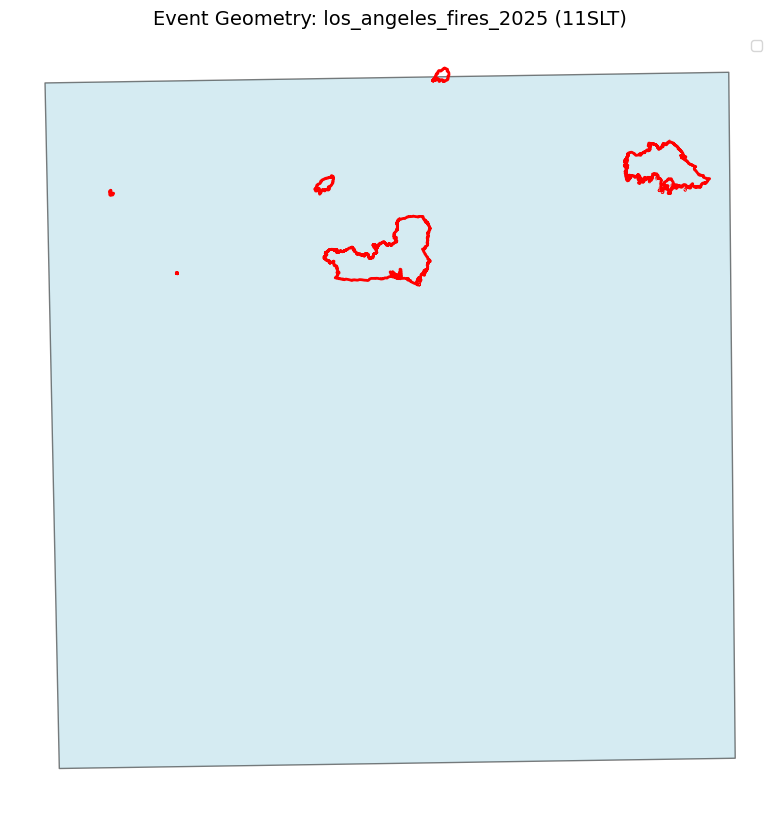

In [91]:
# Preview the selected event extent and perimeter
event_extent = gpd.GeoSeries([event_extents_gdf.iloc[event_idx].geometry], crs=event_extents_gdf.crs)
event_perimeters = gpd.GeoSeries([event_perimeters_gdf.iloc[event_idx].geometry], crs=event_perimeters_gdf.crs)

fig, ax = plt.subplots(figsize=(10, 10))
event_extent.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.5, label="Event Extent")
event_perimeters.plot(ax=ax, color="none", edgecolor="red", linewidth=2, label="Event Perimeter (Ground Truth)")
ax.set_title(f'Event Geometry: {EVENT_NAME} ({AVAILABLE_MGRS[tile_idx]})', fontsize=14)
ax.set_axis_off()
ax.legend()
plt.show()

## Event Loading

In [92]:
# Read and plot the metrics and the status layers
results, metrics, dates, tracks, arr_crs, arr_trans = load_dist_products_from_dirs(EVENT_PATH)
print(f'Loaded {len(results)} timesteps.')
print(f'Tracks in series: {list(set(tracks))}')
print(f'Raster crs: {arr_crs}')
print(f'Raster transform: {arr_trans}')
print(f'Start date: {dates[0]}')
print(f'End date: {dates[-1]}') 

# get the number of days-range of the series
base_date = datetime(2020, 12, 31) # base date for the product
day_start = (dates[0] - base_date).days
day_end = (dates[-1] - base_date).days
print('Number of days since base date in the series', day_start, day_end)

# Find the first DIST-S1 product after the event date
print('Event name:', EVENT_NAME)
print('MGRS tile:', AVAILABLE_MGRS[tile_idx])
print('Event date:', EVENT_DATE)
closest_after_date = find_closest_after_date(EVENT_DATE, dates)
print(f"Closest product after event: {closest_after_date[1]} at index {closest_after_date[0]} (Δ = {closest_after_date[2]/86400:.2f} days)")

Loaded 30 timesteps.
Tracks in series: ['T071', 'T064', 'T144', 'T137']
Raster crs: EPSG:32611
Raster transform: | 30.00, 0.00, 300000.00|
| 0.00,-30.00, 3800040.00|
| 0.00, 0.00, 1.00|
Start date: 2024-12-09 01:58:42
End date: 2025-03-03 14:00:56
Number of days since base date in the series 1439 1523
Event name: los_angeles_fires_2025
MGRS tile: 11SLT
Event date: 2025-01-04
Closest product after event: 2025-01-09 01:50:31 at index 10 (Δ = 5.08 days)


In [93]:
# Select the timestep closest to the event
best_idx = closest_after_date[0]
print(f'Comparing at index: {best_idx}')
print('Event date:', EVENT_DATE)
print('Closest Product to Event:', dates[best_idx])

Comparing at index: 10
Event date: 2025-01-04
Closest Product to Event: 2025-01-09 01:50:31


In [94]:
# Plot results for event
# Define subset for plotting
# s = np.s_[500:1500, 1000:2000] # set subset here as [ymin:ymax, xmin:xmax].
s = np.s_[:,:] # uncomment to plot full extent. 

# Adjust to improve visualization
custom_ranges = [
    (0, 6),          # Metric
    (0, 10),          # Status
    (0, 10),         # Max metric
    (0, 32),         # Confidence
    (day_start, day_end), # Last date
    (0, 30),         # Count
    (0, 150),         # Percent
    (0, 20),         # Duration
    (day_start, day_end),  # Last obs
]

In [95]:
# # s = np.s_[300:700, 3000:3600] # eaton fire
# # plot_disturbance_results_with_metric(results, metrics, subset=s, value_ranges=custom_ranges, dates=dates, tracks=tracks, panels=["Metric", "Status"])
# print('Event date:', EVENT_DATE)
# plot_and_export_disturbance_products(results, 
#                                      metrics, 
#                                      subset=s, 
#                                      value_ranges=custom_ranges, 
#                                      dates=dates, 
#                                      tracks=tracks,  
#                                      panels=["Metric", "Status"],
#                                      out_dir=EVENT_OUT_PATH,
#                                      save_pngs=False, 
#                                      make_animation=False)

In [96]:
def plot_metric_evolution(
    metric_arr, 
    dates, 
    closest_after_date, 
    subset=np.s_[:, :], 
    value_range=(0, 10),
    cols=4,
    zoom=np.s_[:, :],
    out_dir=Path("./metric_plots"),
    save_fig=False
):
    """
    Plots the evolution of the 'Metric' array over time, 
    highlighting the observation immediately following the event.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    
    num_steps = len(metric_arr)
    rows = (num_steps + cols - 1) // cols

    # Extract event details
    event_idx = closest_after_date[0]
    event_date_str = closest_after_date[1]

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for i in range(num_steps):
        ax = axes[i]
        data = metric_arr[i][subset]
        
        # Determine if this is the 'After Event' date
        is_event = (i == event_idx)
        
        # Plotting the metric
        im = ax.imshow(
            data[zoom], 
            cmap="viridis", 
            vmin=value_range[0], 
            vmax=value_range[1], 
            interpolation="none"
        )
        
        # Title with index and date
        date_label = dates[i].strftime("%Y-%m-%d") if dates is not None else f"Step {i}"
        title = f"Idx: {i} | {date_label}"
        
        if is_event:
            ax.set_title(f"POST-EVENT: {title}", fontsize=10, color='red', fontweight='bold')
            # Add a red border to the highlight axis
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)
        else:
            ax.set_title(title, fontsize=10)

        ax.set_xticks([])
        ax.set_yticks([])

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Add a global colorbar
    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Metric Value")
    
    plt.suptitle(f"Metric Series {EVENT_LIST[dta_idx]}_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}\n(Event date:{event_date_str})", fontsize=16, y=0.98)
    
    if save_fig:
        out_path = out_dir / f"metric_series_{EVENT_LIST[dta_idx]}_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}.png"
        plt.savefig(out_path, bbox_inches='tight', dpi=200)
        print(f"Saved plot to {out_path}")
        
    plt.show()

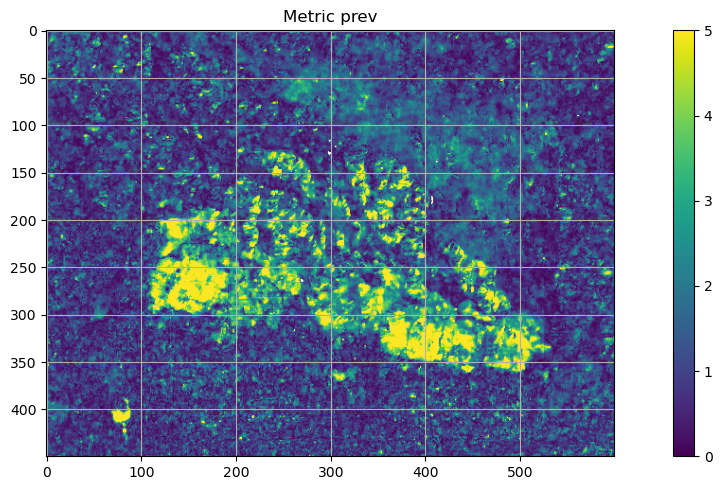

In [97]:
# s = np.s_[3100:3250, 2000:2150] # Papua set subset here as [ymin:ymax, xmin:xmax]. 
# s = np.s_[700:1300, 1250:2100] # Palisades
s = np.s_[250:700, 3000:3600] # Eaton
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 1, 1)
cax = ax.imshow(metrics[14][s], vmin=0, vmax=5, cmap='viridis')
ax.set_title("Metric prev")
fig.colorbar(cax, ax=ax, orientation='vertical')
plt.grid(True)
plt.tight_layout()
plt.show()

Saved plot to metric_plots/metric_series_confirmed_products_dist-event-20max-v1_32_los_angeles_fires_2025_11SLT.png


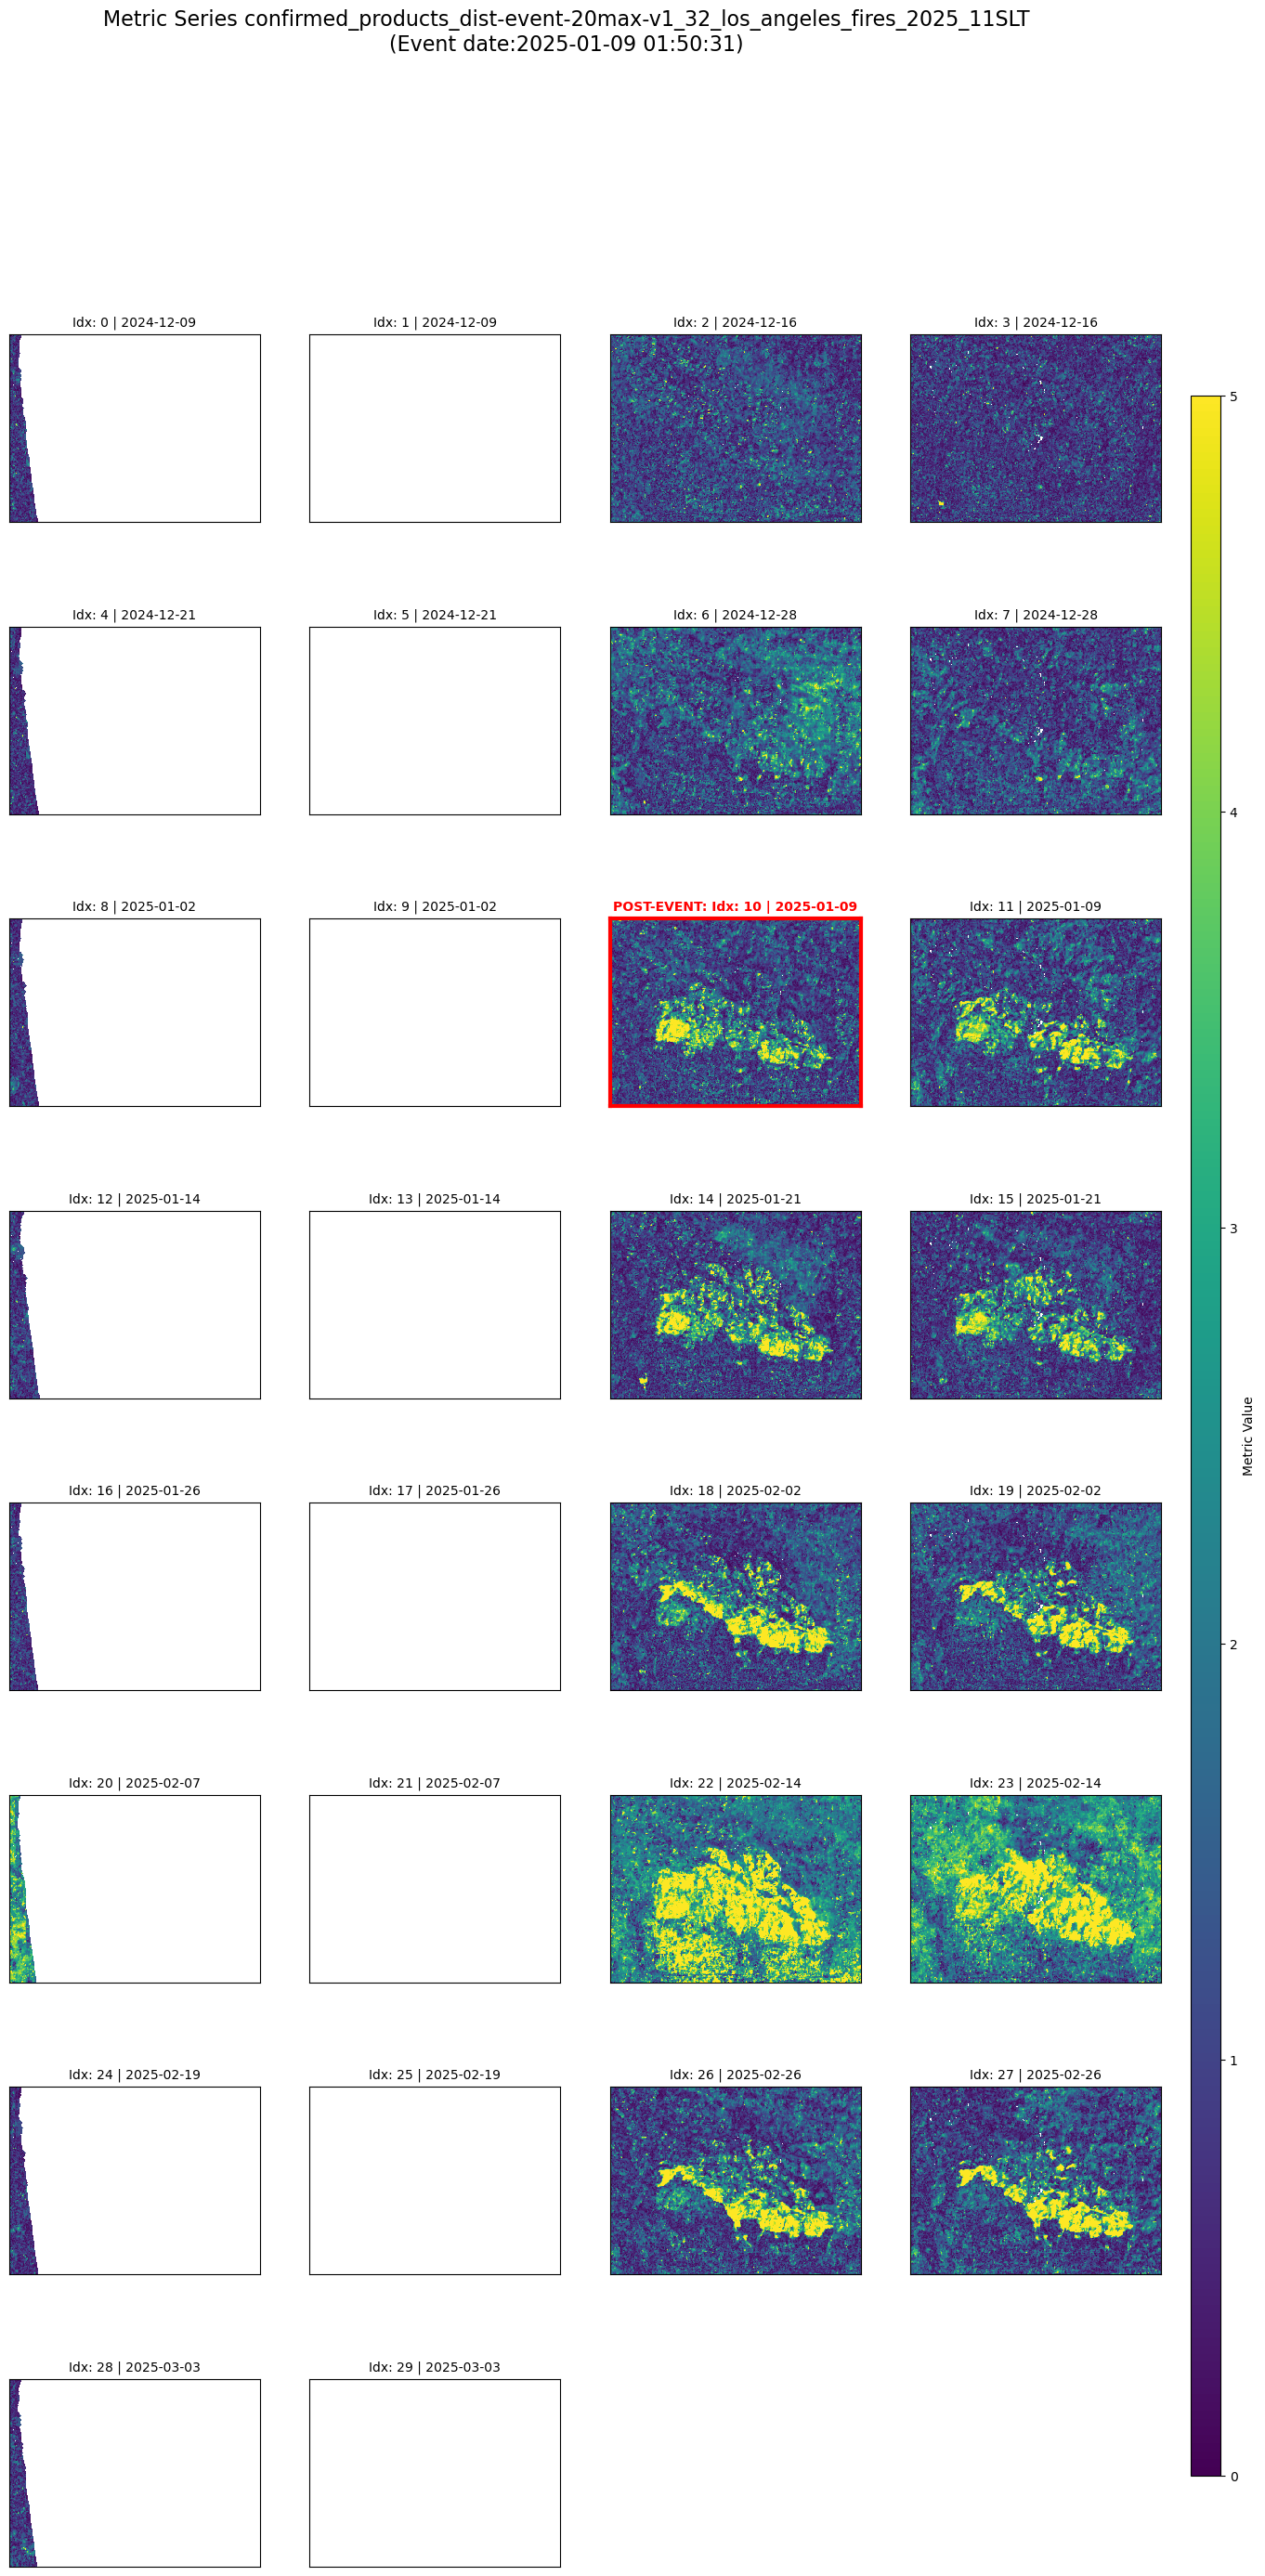

In [98]:
plot_metric_evolution(
    metric_arr=metrics, 
    dates=dates, 
    closest_after_date=[closest_after_date[0], closest_after_date[1]],
    value_range=(0, 5),
    zoom=s,
    save_fig=True,
)

In [99]:
no_dist_metric_idx = 0
high_metric_idx = 14


## Analysis masks

In [100]:
# Create masks for analysis
# AOI mask: Event extent (excludes NoData areas)
aoi_mask = rasterize_polygon(event_extent, results[best_idx][0])
aoi_mask = aoi_mask.astype(bool) & (~np.isnan(results[best_idx][0]))

# Validation mask: Event perimeter (ground truth boundary)
val_mask = rasterize_polygon(event_perimeters, results[best_idx][0])
val_mask = val_mask.astype(bool)

print(f"AOI mask contains {np.sum(aoi_mask)} pixels")
print(f"Validation mask contains {np.sum(val_mask)} pixels")

AOI mask contains 13395600 pixels
Validation mask contains 176475 pixels


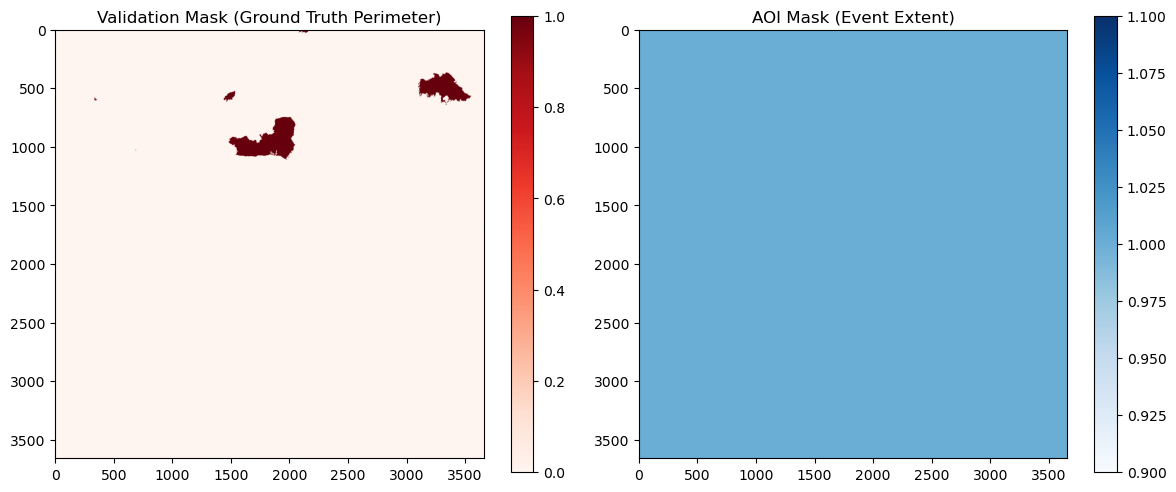

In [101]:
# Visualize the masks
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 1)
cax = ax.imshow(val_mask, cmap='Reds')
ax.set_title("Validation Mask (Ground Truth Perimeter)")
fig.colorbar(cax, ax=ax, orientation='vertical')

ax = fig.add_subplot(1, 2, 2)
cax = ax.imshow(aoi_mask, cmap='Blues')
ax.set_title("AOI Mask (Event Extent)")
fig.colorbar(cax, ax=ax, orientation='vertical')

plt.tight_layout()
plt.show()

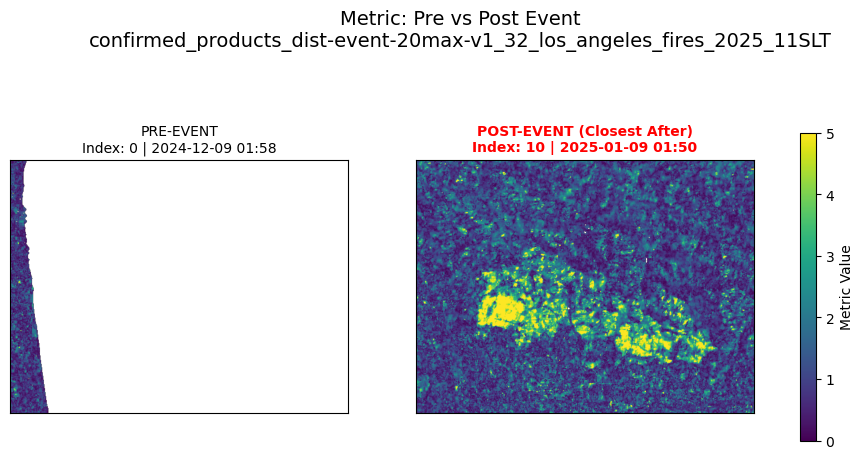

In [102]:
plot_event_comparison(metrics, dates, no_dist_metric_idx, closest_after_date[0],subset=s, value_range=(0, 5))

In [103]:
# Run the analysis
data = get_event_analysis_data(metrics[no_dist_metric_idx], metrics[closest_after_date[0]], aoi_mask, val_mask)


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2078039/2118223431.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.annotate(f'$\max(F_1)=${data['summary']['max_f1']:1.2f}', (data['summary']['best_recall'] + .01, data['summary']['best_precision'] + .01))


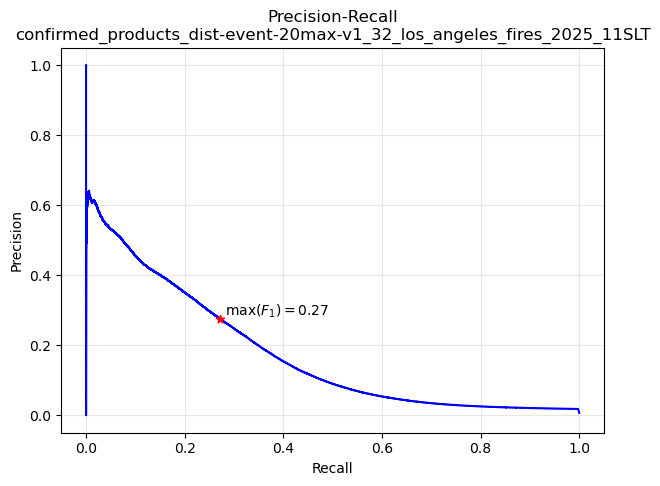

In [104]:
# --- PLOT 1: Precision-Recall Curve ---
plt.figure(figsize=(7, 5))
plt.plot(data['recalls'], data['precisions'], color='blue', label='PR Curve')
# plt.scatter(data['summary']['best_recall'], data['summary']['best_precision'], color='red', marker='*')
plt.scatter(data['summary']['best_recall'], data['summary']['best_precision'], marker='*', c='red', zorder=2)
plt.annotate(f'$\max(F_1)=${data['summary']['max_f1']:1.2f}', (data['summary']['best_recall'] + .01, data['summary']['best_precision'] + .01))

plt.title(f"Precision-Recall\n{EVENT_LIST[dta_idx]}_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.show()


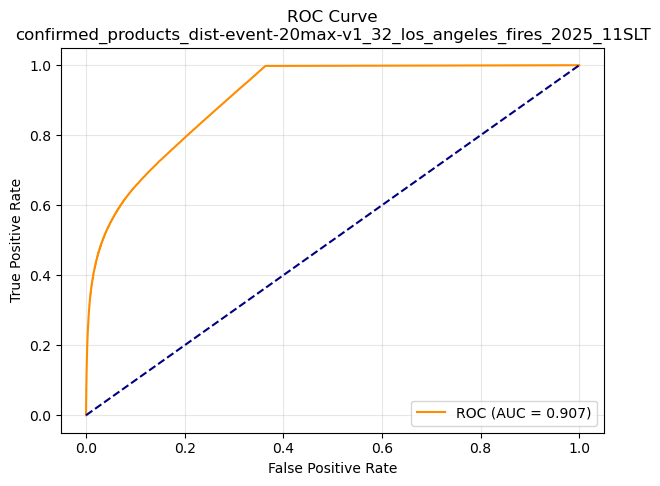

In [105]:
# --- PLOT 2: ROC Curve ---
plt.figure(figsize=(7, 5))
plt.plot(data['fpr'], data['tpr'], color='darkorange', label=f"ROC (AUC = {data['auc_val']:.3f})")
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Diagonal baseline
plt.title(f"ROC Curve\n{EVENT_LIST[dta_idx]}_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}")
plt.legend(loc="best")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True, alpha=0.3)
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2078039/2265131309.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.annotate(f'$\max(F_1)=${data['summary']['max_f1']:1.2f}', (data['summary']['best_threshold'] + .001, data['summary']['max_f1'] + .001))


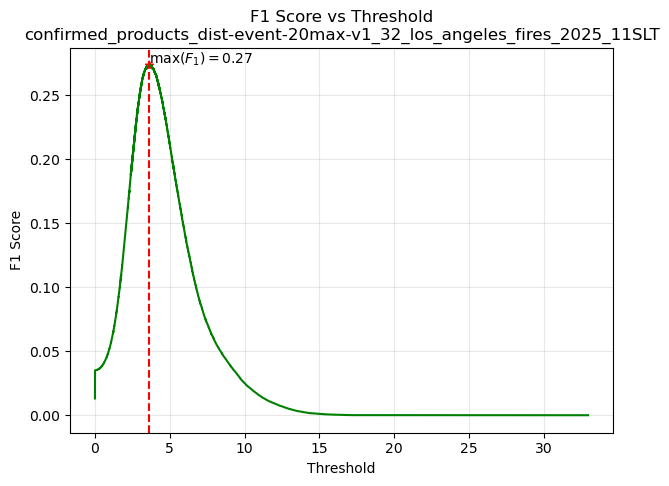

In [106]:
# --- PLOT 3: F1 vs Threshold ---
plt.figure(figsize=(7, 5))
plt.scatter(data['summary']['best_threshold'], data['summary']['max_f1'], marker='*', c='red', zorder=2)
plt.annotate(f'$\max(F_1)=${data['summary']['max_f1']:1.2f}', (data['summary']['best_threshold'] + .001, data['summary']['max_f1'] + .001))
plt.plot(data['f1_thresholds'], data['f1_scores'], color='green')
plt.axvline(data['summary']['best_threshold'], color='red', linestyle='--', label='Best Threshold')
plt.title(f"F1 Score vs Threshold\n{EVENT_LIST[dta_idx]}_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.grid(True, alpha=0.3)
plt.show()

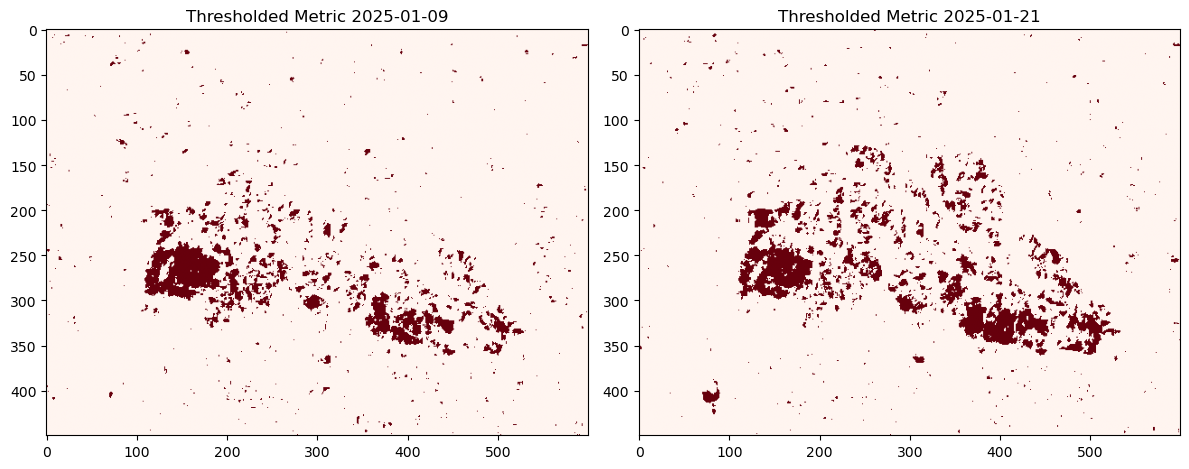

In [107]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 1)
cax = ax.imshow(metrics[closest_after_date[0]][s] > data['summary']['best_threshold'], cmap='Reds')
ax.set_title(f"Thresholded Metric {dates[closest_after_date[0]].strftime('%Y-%m-%d')}")

ax = fig.add_subplot(1, 2, 2)
cax = ax.imshow(metrics[high_metric_idx][s] > data['summary']['best_threshold'], cmap='Reds')
ax.set_title(f"Thresholded Metric {dates[high_metric_idx].strftime('%Y-%m-%d')}")

plt.tight_layout()
plt.show()

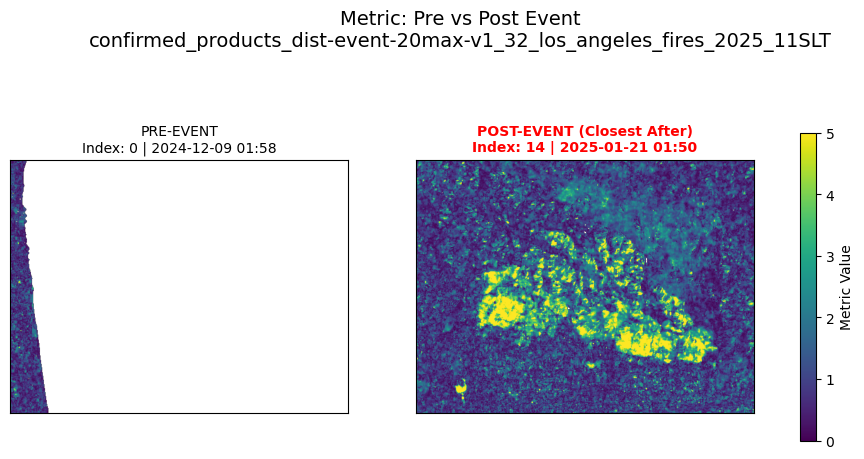

In [108]:
plot_event_comparison(metrics, dates, no_dist_metric_idx, high_metric_idx, subset=s, value_range=(0, 5))

In [109]:
# Run the analysis
data = get_event_analysis_data(metrics[no_dist_metric_idx], metrics[high_metric_idx], aoi_mask, val_mask)


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2078039/3035059309.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.annotate(f'$\max(F_1)=${data['summary']['max_f1']:1.2f}', (data['summary']['best_recall'] + .01, data['summary']['best_precision'] + .01))


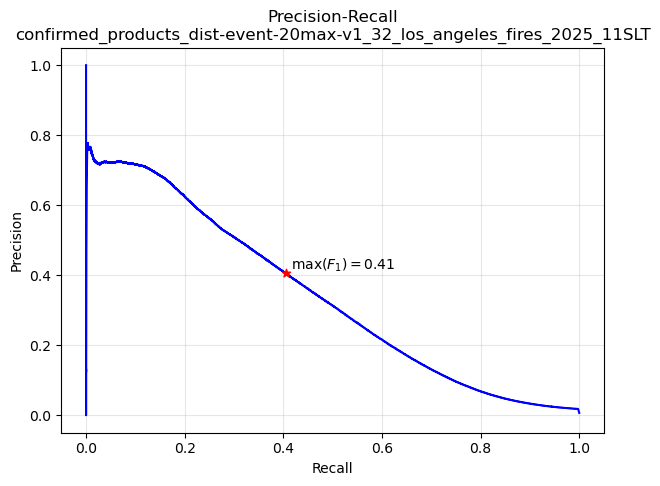

In [110]:
# --- PLOT 1: Precision-Recall Curve ---
plt.figure(figsize=(7, 5))
plt.plot(data['recalls'], data['precisions'], color='blue', label='PR Curve')
# plt.scatter(data['summary']['best_recall'], data['summary']['best_precision'], color='red', marker='*')
plt.scatter(data['summary']['best_recall'], data['summary']['best_precision'], marker='*', c='red', zorder=2)
plt.annotate(f'$\max(F_1)=${data['summary']['max_f1']:1.2f}', (data['summary']['best_recall'] + .01, data['summary']['best_precision'] + .01))

plt.title(f"Precision-Recall\n{EVENT_LIST[dta_idx]}_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.show()

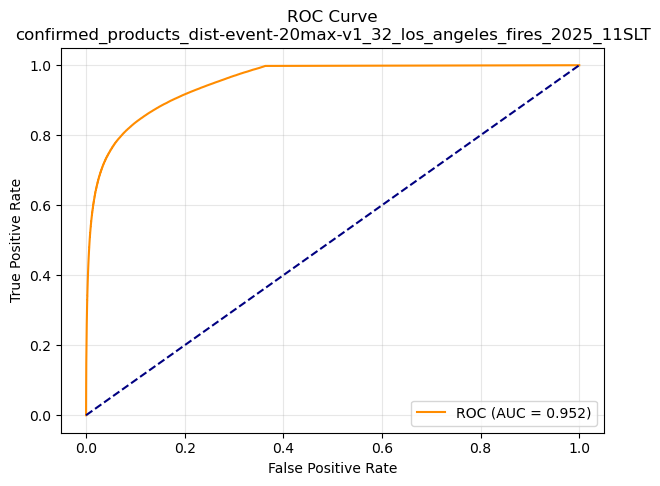

In [111]:
# --- PLOT 2: ROC Curve ---
plt.figure(figsize=(7, 5))
plt.plot(data['fpr'], data['tpr'], color='darkorange', label=f"ROC (AUC = {data['auc_val']:.3f})")
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Diagonal baseline
plt.title(f"ROC Curve\n{EVENT_LIST[dta_idx]}_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}")
plt.legend(loc="best")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True, alpha=0.3)
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2078039/2265131309.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.annotate(f'$\max(F_1)=${data['summary']['max_f1']:1.2f}', (data['summary']['best_threshold'] + .001, data['summary']['max_f1'] + .001))


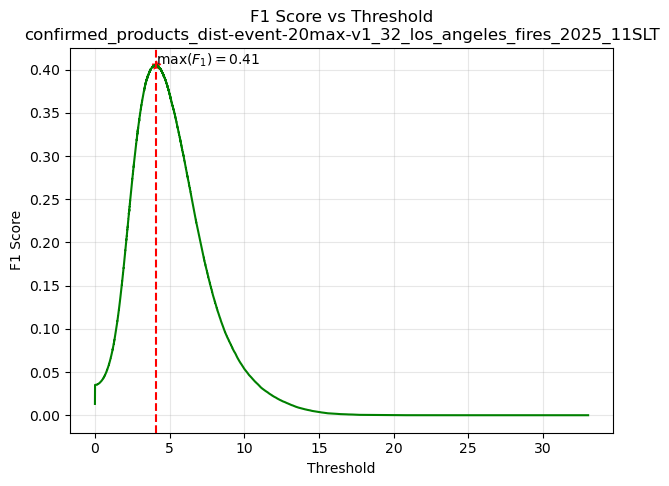

In [112]:
# --- PLOT 3: F1 vs Threshold ---
plt.figure(figsize=(7, 5))
plt.scatter(data['summary']['best_threshold'], data['summary']['max_f1'], marker='*', c='red', zorder=2)
plt.annotate(f'$\max(F_1)=${data['summary']['max_f1']:1.2f}', (data['summary']['best_threshold'] + .001, data['summary']['max_f1'] + .001))
plt.plot(data['f1_thresholds'], data['f1_scores'], color='green')
plt.axvline(data['summary']['best_threshold'], color='red', linestyle='--', label='Best Threshold')
plt.title(f"F1 Score vs Threshold\n{EVENT_LIST[dta_idx]}_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.grid(True, alpha=0.3)
plt.show()

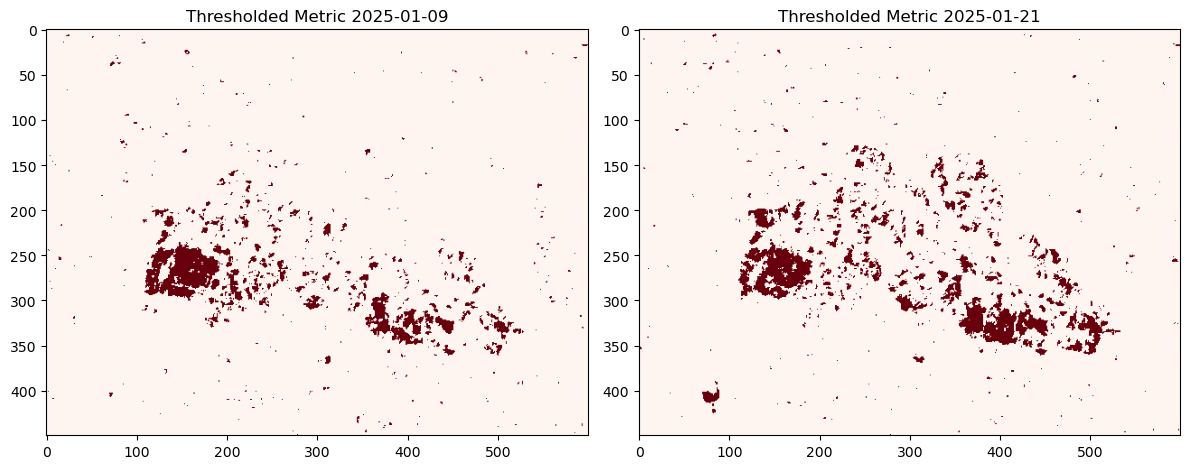

In [113]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 1)
cax = ax.imshow(metrics[closest_after_date[0]][s] > data['summary']['best_threshold'], cmap='Reds')
ax.set_title(f"Thresholded Metric {dates[closest_after_date[0]].strftime('%Y-%m-%d')}")

ax = fig.add_subplot(1, 2, 2)
cax = ax.imshow(metrics[high_metric_idx][s] > data['summary']['best_threshold'], cmap='Reds')
ax.set_title(f"Thresholded Metric {dates[high_metric_idx].strftime('%Y-%m-%d')}")

plt.tight_layout()
plt.show()

In [114]:
def plot_thresholded_evolution(
    metric_arr, 
    dates, 
    closest_after_date, 
    threshold,
    subset=np.s_[:, :], 
    cols=4,
    zoom=np.s_[:, :],
    out_dir=Path("./threshold_plots"),
    save_fig=False
):
    """
    Plots the evolution of the metric array thresholded by 'threshold'.
    Highlights the post-event observation with a red border.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    
    num_steps = len(metric_arr)
    rows = (num_steps + cols - 1) // cols
    
    event_idx = closest_after_date[0]
    event_date_str = closest_after_date[1]

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for i in range(num_steps):
        ax = axes[i]
        
        # --- APPLY THRESHOLD HERE ---
        # data becomes a boolean mask (True/False)
        raw_data = metric_arr[i][subset]
        thresholded_data = raw_data > threshold
        
        is_event = (i == event_idx)
        
        # Plotting with the 'Reds' colormap
        im = ax.imshow(
            thresholded_data[zoom], 
            cmap="Reds", 
            interpolation="none"
        )
        
        date_label = dates[i].strftime("%Y-%m-%d") if dates is not None else f"Step {i}"
        title = f"Idx: {i} | {date_label}"
        
        if is_event:
            ax.set_title(f"POST-EVENT: {title}", fontsize=10, color='red', fontweight='bold')
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)
        else:
            ax.set_title(title, fontsize=10)

        ax.set_xticks([])
        ax.set_yticks([])

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Adjust layout and add header
    plt.suptitle(
        f"Thresholded Metric ( > {threshold:.4f})\n"
        f"{EVENT_LIST[dta_idx]}_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}\n"
        f"(Event date: {event_date_str})", 
        fontsize=16, y=0.98
    )
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Leave space for suptitle
    
    if save_fig:
        out_path = out_dir / f"thresholded_series_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}.png"
        plt.savefig(out_path, bbox_inches='tight', dpi=200)
        print(f"Saved thresholded plot to {out_path}")
        
    plt.show()

Saved thresholded plot to threshold_plots/thresholded_series_los_angeles_fires_2025_11SLT.png


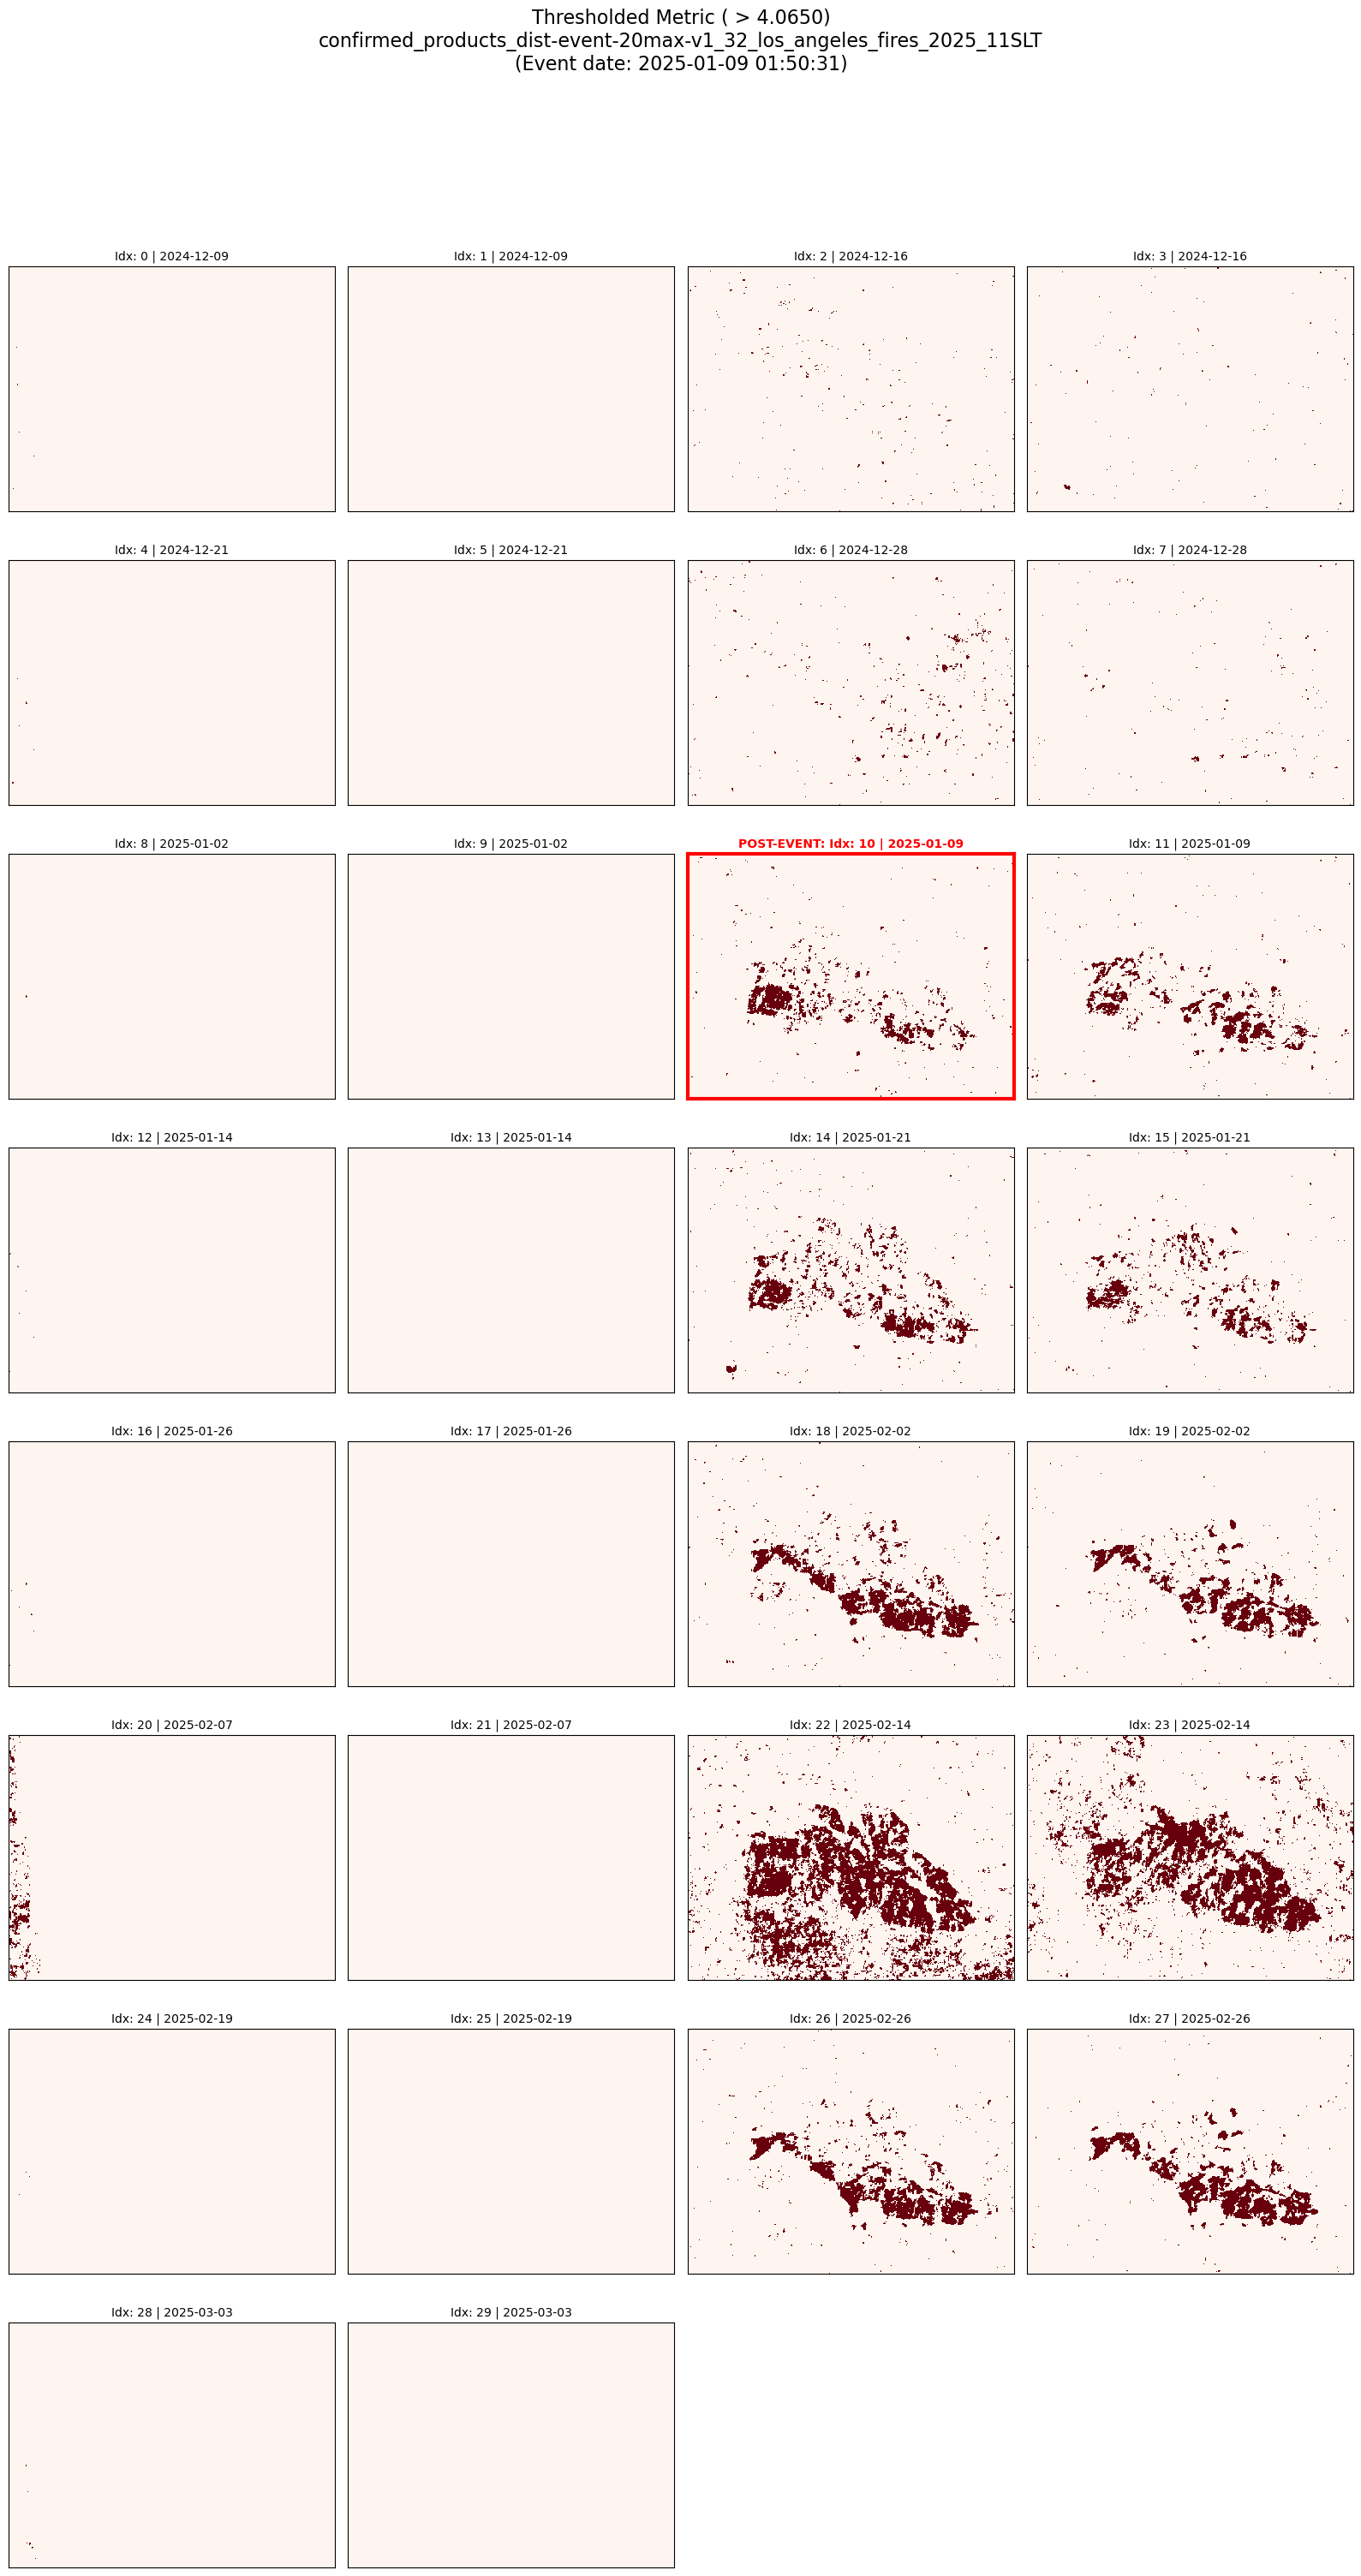

In [115]:
plot_thresholded_evolution(
    metric_arr=metrics,
    dates=dates,
    closest_after_date=closest_after_date,
    zoom=s,
    threshold=data['summary']['best_threshold'], # From your analysis data
    save_fig=True
)

In [116]:
def calculate_width_at_percent(thresholds, f1_scores, percentage=0.75):
    # 1. Identify the peak and the target value (e.g., 75% of max)
    max_f1 = np.max(f1_scores)
    target_value = max_f1 * percentage
    
    # 2. Find indices where f1 is above the target
    indices_above = np.where(f1_scores >= target_value)[0]
    
    if len(indices_above) < 2:
        return None, None, None

    # 3. Get the start and end indices
    first_idx = indices_above[0]
    last_idx = indices_above[-1]
    
    # 4. Linear Interpolation for precision
    # Left side: interpolate between the point just before and the first point above
    t_left = np.interp(target_value, f1_scores[:first_idx+1], thresholds[:first_idx+1])
    
    # Right side: interpolate between the last point above and the point just after
    # We flip for interp because the x-axis (f1_scores) must be increasing
    t_right = np.interp(target_value, f1_scores[last_idx:][::-1], thresholds[last_idx:][::-1])
    
    width = t_right - t_left
    
    return width, t_left, t_right

# --- Execution ---
fw75m, t_left, t_right = calculate_width_at_percent(data['f1_thresholds'], data['f1_scores'], percentage=0.75)

print(f"Full Width at 75% Max (FW75M): {fw75m:.4f}")
print(f"Threshold Range: {t_left:.4f} to {t_right:.4f}")

Full Width at 75% Max (FW75M): 3.1939
Threshold Range: 2.6919 to 5.8858


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2078039/1385794816.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.annotate(f'$\max(F_1)=${data['summary']['max_f1']:1.2f}', (data['summary']['best_threshold'] + .001, data['summary']['max_f1'] + .001))


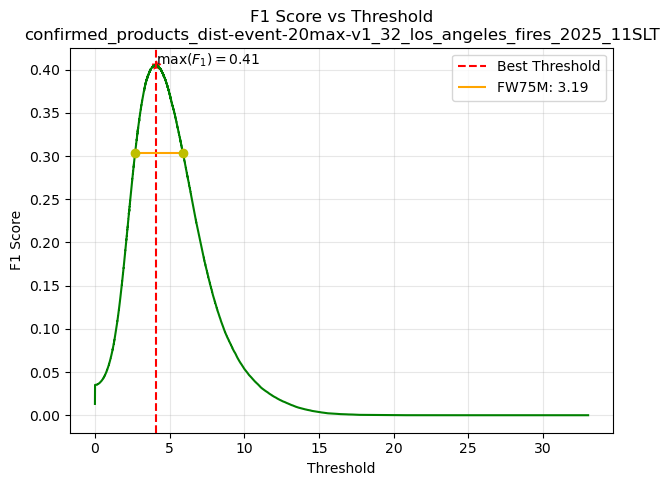

In [117]:
plt.figure(figsize=(7, 5))
plt.scatter(data['summary']['best_threshold'], data['summary']['max_f1'], marker='*', c='red', zorder=2)
plt.annotate(f'$\max(F_1)=${data['summary']['max_f1']:1.2f}', (data['summary']['best_threshold'] + .001, data['summary']['max_f1'] + .001))
plt.plot(data['f1_thresholds'], data['f1_scores'], color='green')
plt.axvline(data['summary']['best_threshold'], color='red', linestyle='--', label='Best Threshold')
plt.title(f"F1 Score vs Threshold\n{EVENT_LIST[dta_idx]}_{EVENT_NAME}_{AVAILABLE_MGRS[tile_idx]}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.grid(True, alpha=0.3)

if fw75m:
    target_f1 = data['summary']['max_f1'] * 0.75
    plt.hlines(y=target_f1, xmin=t_left, xmax=t_right, 
               color='orange', linestyle='-', label=f'FW75M: {fw75m:.2f}')
    plt.plot([t_left, t_right], [target_f1, target_f1], 'yo') # yellow dots at intersections
    plt.legend()

plt.show()